# Job training and subsequent earnings: matching
**Question:** How does enrolling in Job Training Partnership Act (JTPA) services affect subsequent earnings.

Now that we have used an instrument to uncover a causal estimate of the effect of job training on compliers, we will now do an analysis using matching as an exercise, to see if we can recover the causal estimate using this method without relying on the random assignment.

## Important considerations

1. Matching will likely not recover a causal estimate.  This is because we have unobserved variables like motivation, baseline skills, and local market conditions that are confoundrs, so a matching estimate will likely still be biased unless our observed variables can account for those unobseved ones.  I suspect our estimate to land somewhere between the $2791 naive estimate and the $1770 IV estimate.

2. We will not match on offer, or use it in any way.  The goal of this notebook is to simulate the analysis as if we never had the randomized assignment.  

3. Our matching estimate will still differ from IV even if we have no bias. This is because IV gives the effect for compliers (those who enroll when offered), and matching will give the effect for everyone (income change if enrolled).  However, if we average the difference in income only over the treated population, we get close to the same quantity as that our IV estimate was finding, since only 1.45% of the not-offered group enroll.  

### Why not match on offer?

Even setting the exercise aside, offer is the wrong thing to match on.  It is random, so it is not a confounder and matching on it removes no bias.  What it does remove is the clean variation in enrollment: among people with the same offer, the only reason one enrolled and another did not is personal choice, which is exactly the selection we are worried about, so the bias gets larger.  It also wrecks overlap, since almost nobody without an offer enrolled.

## 1. Data and encoding

We one-hot encode every level of every control, including both levels of each binary and the omitted age band, and leave the columns unscaled.  Each person then has exactly one 1 per variable, so the squared distance between two people is 2 x the number of variables they differ on, and every mismatch costs the same.  Notice that this would be wrong for regression because it causes colinearity.

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)

In [2]:
# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data/raw/jtpa.raw").is_file()
        and (path / "docs/data_dictionary.csv").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside job-training-causal-inference.")
PROCESSED_DATA = PROJECT_ROOT / "data/processed/jtpa_preprocessed.csv"
CONTROLS_FILE = PROJECT_ROOT / "data/processed/baseline_controls.json"
if not PROCESSED_DATA.is_file():
    raise FileNotFoundError("Run 01_data_preprocessing.ipynb first.")
if not CONTROLS_FILE.is_file():
    raise FileNotFoundError("Run 02_dag_and_controls.ipynb first.")
FIGURES_DIR = PROJECT_ROOT / "outputs/figures"
TABLES_DIR = PROJECT_ROOT / "outputs/tables"
for directory in (FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)
Y, T = "earnings_30mo", "enrolled"
print(f"Project: {PROJECT_ROOT}\nPython: {sys.version.split()[0]}")
print(
    " | ".join(
        f"{name} {version(name)}"
        for name in [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "statsmodels",
            "scikit-learn",
        ]
    )
)

Project: /Users/drewmathieson/Projects/job-training-causal-inference
Python: 3.14.3
numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1 | seaborn 0.13.2 | statsmodels 0.14.6 | scikit-learn 1.9.0


In [3]:
# CSV drops the category order, so restore it to keep the same reference levels.
status_categories = {
    "married": ["Not married", "Married", "Unknown"],
    "hsorged": ["No diploma/GED", "Diploma/GED", "Unknown"],
    "prior_employment_status": [
        "Worked 13 weeks or more in prior year",
        "Worked less than 13 weeks in prior year",
        "Unknown",
    ],
}
df = pd.read_csv(PROCESSED_DATA)
for name, categories in status_categories.items():
    df[name] = pd.Categorical(df[name], categories=categories)
assert df.notna().all().all(), "Unexpected category labels or missing values."

# The control set is chosen in 02_dag_and_controls.ipynb. Offer is deliberately unused.
control_columns = json.loads(CONTROLS_FILE.read_text())
control_terms = " + ".join(
    f"C({name})" if name in status_categories else name for name in control_columns
)
treated = df[T].eq(1)
print(
    f"Loaded {len(df):,} people: {treated.sum():,} enrolled, {(~treated).sum():,} not enrolled."
)

Loaded 11,204 people: 4,858 enrolled, 6,346 not enrolled.


In [4]:
# Collapse the age dummies into one variable so the omitted band gets its own level.
age_columns = [name for name in control_columns if name.startswith("age")]
profile = df[[name for name in control_columns if name not in age_columns]].copy()
profile.insert(
    0,
    "age_band",
    df[age_columns].idxmax(axis=1).where(df[age_columns].any(axis=1), "age_other"),
)

# One column per level of every variable, unscaled.
X = pd.get_dummies(profile.astype(str), prefix_sep="=", dtype=float)
assert X.sum(axis=1).eq(profile.shape[1]).all(), "Expected one level per variable."
print(f"{profile.shape[1]} variables encoded as {X.shape[1]} columns.")
display(X.head())

10 variables encoded as 27 columns.


,age_band=age2225,age_band=age2629,age_band=age3035,age_band=age3644,age_band=age4554,age_band=age_other,married=Married,married=Not married,married=Unknown,hsorged=Diploma/GED,hsorged=No diploma/GED,hsorged=Unknown,...,black=0,black=1,hispanic=0,hispanic=1,male=0,male=1,afdc=0,afdc=1,class_tr=0,class_tr=1,ojt_jsa=0,ojt_jsa=1
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


## 2. Balance and overlap checks

Before matching, we check how different the enrolled and not enrolled are on the controls (balance), and whether each group contains people comparable to the other (overlap).  Balance is measured with the standardized mean difference: the difference in means divided by the pooled standard deviation, where an absolute value above 0.1 is the usual flag for a meaningful imbalance.

In [5]:
def balance_table(X, treated, weights=None):
    """Standardized mean differences between the enrolled and not enrolled.

    Pass match weights to rebuild the table for a matched sample; the denominator
    always uses the unweighted standard deviations so the tables stay comparable.
    """
    weights = np.ones(len(X)) if weights is None else np.asarray(weights, dtype=float)
    mean_treated = np.average(X[treated], axis=0, weights=weights[treated])
    mean_untreated = np.average(X[~treated], axis=0, weights=weights[~treated])
    pooled_sd = np.sqrt((X[treated].var() + X[~treated].var()) / 2)
    return pd.DataFrame(
        {
            "Enrolled": mean_treated,
            "Not enrolled": mean_untreated,
            "Std. mean difference": (mean_treated - mean_untreated) / pooled_sd,
        },
        index=X.columns,
    )


# The two levels of a binary mirror each other, so show only the "=1" row.
balance_levels = [name for name in X.columns if not name.endswith("=0")]
balance_before = balance_table(X, treated).loc[balance_levels]
display(
    balance_before.sort_values(
        "Std. mean difference", key=abs, ascending=False
    ).style.format(
        {
            "Enrolled": "{:.1%}",
            "Not enrolled": "{:.1%}",
            "Std. mean difference": "{:+.3f}",
        }
    )
)

,Enrolled,Not enrolled,Std. mean difference
class_tr=1,36.6%,25.2%,+0.249
ojt_jsa=1,38.5%,47.0%,-0.173
hsorged=No diploma/GED,24.8%,29.3%,-0.101
hsorged=Diploma/GED,69.1%,64.4%,+0.100
male=1,44.0%,46.7%,-0.056
afdc=1,19.9%,17.8%,+0.053
age_band=age4554,7.4%,8.9%,-0.052
married=Not married,65.6%,67.9%,-0.049
prior_employment_status=Unknown,9.7%,11.1%,-0.047
married=Married,27.4%,25.4%,+0.046


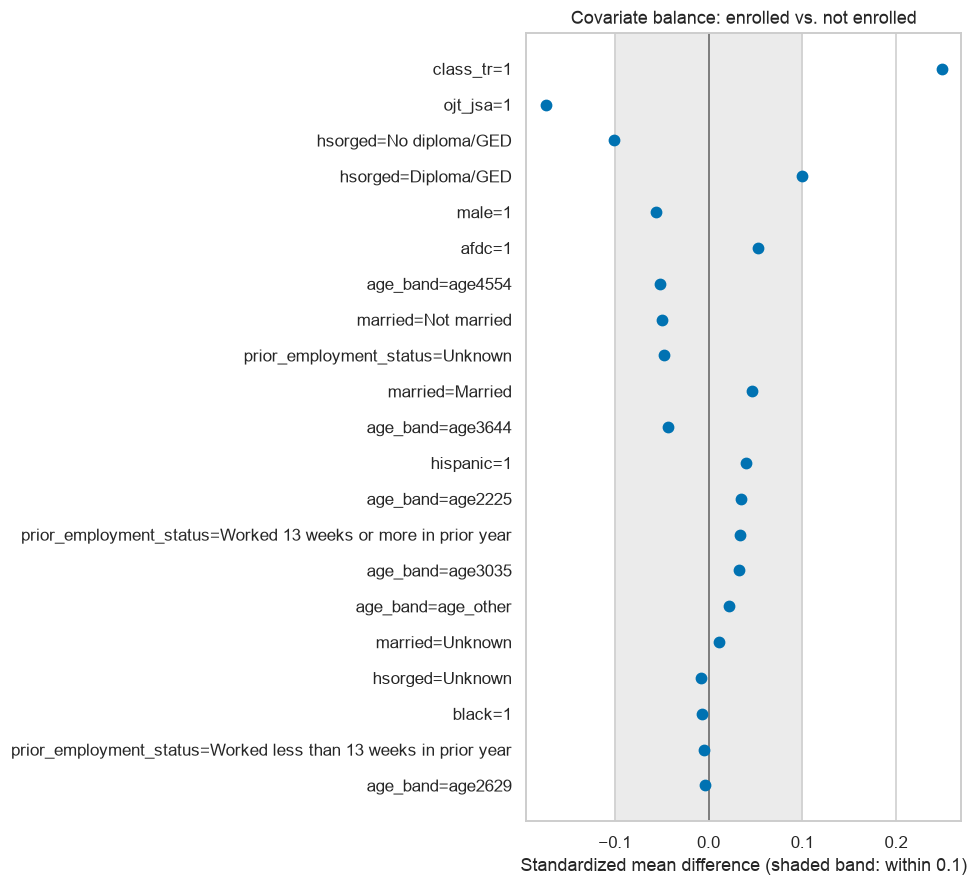

In [6]:
def plot_balance(tables, filename):
    """Dot plot of standardized mean differences; pass {label: balance table}."""
    order = (
        next(iter(tables.values()))["Std. mean difference"].abs().sort_values().index
    )
    fig, ax = plt.subplots(figsize=(9, 0.32 * len(order) + 1.5))
    ax.axvspan(-0.1, 0.1, color="0.92", zorder=0)
    ax.axvline(0, color="0.4", linewidth=1)
    for (label, table), color in zip(tables.items(), ["#0072B2", "#D55E00"]):
        ax.scatter(
            table.loc[order, "Std. mean difference"],
            range(len(order)),
            s=45,
            color=color,
            label=label,
            zorder=3,
        )
    ax.set_yticks(range(len(order)), order)
    ax.set(
        title="Covariate balance: enrolled vs. not enrolled",
        xlabel="Standardized mean difference (shaded band: within 0.1)",
    )
    ax.grid(axis="y", visible=False)
    if len(tables) > 1:
        ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()


plot_balance({"Before matching": balance_before}, "matching_balance_before.png")

### Overlap in covariate profiles

Because every control is categorical, we can check overlap directly: for each person, how many variables differ from the closest covariate profile in the other group?  Zero means an exact match exists.

In [7]:
def mismatches_to_nearest(X_from, X_to):
    """Number of variables that differ from the closest profile in the other group."""
    profiles = np.unique(X_to, axis=0)
    shared = X_from @ profiles.T  # variables on which a person and a profile agree
    return (profile.shape[1] - shared.max(axis=1)).astype(int)


X_values = X.to_numpy()
mismatches = pd.Series(0, index=df.index)
mismatches[treated] = mismatches_to_nearest(X_values[treated], X_values[~treated])
mismatches[~treated] = mismatches_to_nearest(X_values[~treated], X_values[treated])

profile_overlap = pd.crosstab(
    mismatches,
    treated.map({True: "Enrolled", False: "Not enrolled"}),
    normalize="columns",
).rename_axis(index="Variables differing from closest match", columns=None)
print(f"Distinct covariate profiles: {len(np.unique(X_values, axis=0)):,}")
display(profile_overlap.style.format("{:.2%}"))

Distinct covariate profiles: 2,135


,Enrolled,Not enrolled
Variables differing from closest match,,
0,87.55%,84.04%
1,12.33%,15.74%
2,0.12%,0.22%


### Overlap in the propensity score

We also estimate each person's probability of enrolling given the controls, using a logistic regression.  Scores near 0 or 1, or regions where only one group appears, would mean some people have no comparable counterpart.

Pseudo R-squared: 0.015 | AUC: 0.581
Common support: 0.282 to 0.613; 2 people fall outside it.


,count,mean,std,min,25%,50%,75%,max
Enrolled,4858.0,0.445,0.073,0.278,0.388,0.427,0.515,0.613
Not enrolled,6346.0,0.425,0.068,0.282,0.376,0.408,0.469,0.625


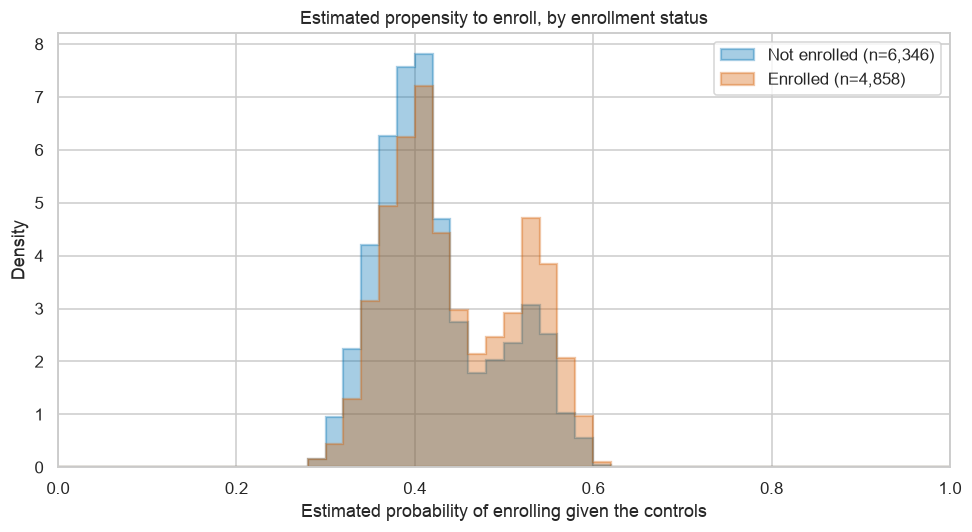

In [8]:
propensity_model = smf.logit(f"{T} ~ {control_terms}", data=df).fit(disp=False)
propensity = propensity_model.predict(df)

common_low = max(propensity[treated].min(), propensity[~treated].min())
common_high = min(propensity[treated].max(), propensity[~treated].max())
outside = (propensity.lt(common_low) | propensity.gt(common_high)).sum()
print(
    f"Pseudo R-squared: {propensity_model.prsquared:.3f} | AUC: {roc_auc_score(df[T], propensity):.3f}"
)
print(
    f"Common support: {common_low:.3f} to {common_high:.3f}; {outside} people fall outside it."
)
display(
    propensity.groupby(treated.map({True: "Enrolled", False: "Not enrolled"}))
    .describe()
    .rename_axis(None)
    .round(3)
)

fig, ax = plt.subplots()
bins = np.linspace(0, 1, 51)
for is_treated, label, color in [
    (False, "Not enrolled", "#0072B2"),
    (True, "Enrolled", "#D55E00"),
]:
    ax.hist(
        propensity[treated == is_treated],
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=0.35,
        color=color,
        edgecolor=color,
        linewidth=1.5,
        label=f"{label} (n={(treated == is_treated).sum():,})",
    )
ax.set(
    title="Estimated propensity to enroll, by enrollment status",
    xlabel="Estimated probability of enrolling given the controls",
    ylabel="Density",
    xlim=(0, 1),
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "matching_propensity_overlap.png", bbox_inches="tight")
plt.show()

### Interpretation

**Balance.** The enrolled and not enrolled already look similar on the observed controls.  The only meaningful differences are in the recommended service strategy (the enrolled were more often recommended classroom training, SMD +0.25, and less often on-the-job training / job-search assistance, SMD -0.17) and in education (more diplomas/GEDs among the enrolled, SMD +0.10).  Every other level is below 0.06, well inside the usual 0.1 threshold.

**Overlap.** Overlap is not a concern.  87.5% of the enrolled and 84.0% of the not enrolled have an exact match in the other group, nearly everyone else differs from their closest match on a single variable, and fewer than 0.3% differ on two.  The estimated propensity scores all sit between 0.28 and 0.63, nowhere near 0 or 1, and only 2 people fall outside the range the two groups share.  The second hump near 0.53 is the group recommended for classroom training, who enrolled at a higher rate; it appears in both groups, so it is an imbalance and not an overlap problem.  Both the effect for everyone and the effect for the treated are supported by the data, so no trimming is needed.

**What this means for the estimate.** The controls barely predict enrollment (pseudo R-squared 0.015, AUC 0.58, where 0.5 is a coin flip).  Good balance here is not evidence that enrollment is unconfounded; it says that whatever drives enrollment is mostly not in our controls.  We know from the IV notebook that a large part of it is the random offer, which is harmless, and the DAG says the rest is unobserved motivation, skills, and local market conditions, which is not harmless.  Matching can only remove imbalance in what we observe, and there is little to remove, so I now expect the matching estimate to stay close to the naive $2,791 rather than move toward the IV estimate.

## 3. Matching algorithm

Because our features are all binary or categorical, we will have many exact matches while finding nearest neighbors.  For this reason, we will average the outcome over all tied matches.  This will give us a less noisy estimate than simply choosing one neighbor at random.

Moreover, the usual bias correction step of using least squares to predict income and subtracting the difference between each person and their match is less important, as those predictions will be identical for the vast majority of our population due to exact matching on the covariates.  I will include them in the algorithm below as best practice however since the purpose of this notebook is learning and implementation.

1. Build a regression model `model_treated` by regressing income on `X` for the treated population.  Do the same for the untreated population to get `model_untreated`.
2. Find the closest untreated neighbors `N_i` on `X` for each treated person `i`.  Calculate `matched_income_i` as the mean income of those neighbors.  Calculate `bias_i = predicted_income_i - mean(predicted_income_j for j in N_i)`, using `model_untreated` for both predictions.  Do the same for each untreated person, using their treated neighbors and `model_treated`.
3. For each individual, calculate `diff_in_income_i = income_i - matched_income_i - bias_i`, noting that `bias_i` will be 0 for the majority of individuals.
4. Estimate the average treatment effect as `mean((2 * enrolled_i - 1) * diff_in_income_i)` over everyone.
5. Estimate the average treatment effect on the treated as `mean(diff_in_income_i)` over enrolled individuals.  This is the number most comparable with our IV estimate.

## 4: Building `model_treated` and `model_untreated`

We regress income on the controls separately within the treated and untreated groups, then predict income for everyone under each model.  These regressions use drop-one-level coding for the controls, since the full one-hot `X` would be collinear.

In [9]:
model_treated = smf.ols(f"{Y} ~ {control_terms}", data=df[treated]).fit()
model_untreated = smf.ols(f"{Y} ~ {control_terms}", data=df[~treated]).fit()

# Predict for everyone: the bias step applies each model to the opposite group.
predicted_income = pd.DataFrame(
    {
        "model_treated": model_treated.predict(df),
        "model_untreated": model_untreated.predict(df),
    }
)
display(
    pd.DataFrame(
        {
            "Fit on": ["Treated", "Untreated"],
            "N": [int(model_treated.nobs), int(model_untreated.nobs)],
            "R-squared": [model_treated.rsquared, model_untreated.rsquared],
        },
        index=["model_treated", "model_untreated"],
    ).round(3)
)
# Mean predicted income under each model, by actual group.
display(
    predicted_income.groupby(treated.map({True: "Treated", False: "Untreated"}))
    .mean()
    .rename_axis(None)
    .round(0)
)

,Fit on,N,R-squared
model_treated,Treated,4858,0.120
model_untreated,Untreated,6346,0.103


,model_treated,model_untreated
Treated,17396.0,14654.0
Untreated,17669.0,14605.0


## 5: Calculating matched income and bias

We will now...
1. Collapse each group, treated and untreated, to its unique covariate profiles, keeping each profile's mean income, predicted income, and count.
2. For each person `i`, find the distance to every covariate profile in the opposite group.  We count the number of variables that differ, which ranks profiles identically to Euclidean distance on `X`.
3. For each person `i`, calculate `matched_income_i` as the count-weighted average income of all minimal-distance profiles (noting that the majority will be distance 0 with only a single profile).
4. For each person `i`, calculate `bias_i = predicted_income_i - matched_predicted_income_i`, where `matched_predicted_income_i` is the count-weighted average predicted income of the same minimal-distance profiles.  Both predictions use the model fit on the opposite group (`model_untreated` for treated individuals, and `model_treated` for untreated).

In [ ]:
def match_to_pool(to_match, pool, predicted):
    """Match each person in `to_match` to the closest profiles in `pool`.

    Both arguments are boolean masks. `predicted` is income predicted for everyone
    by the model fit on the pool's group.
    """
    # 1. Collapse the pool to unique profiles with mean income, prediction, and count.
    profiles, profile_of, counts = np.unique(
        X_values[pool], axis=0, return_inverse=True, return_counts=True
    )
    profile_of = profile_of.ravel()
    profile_income = np.bincount(profile_of, weights=df.loc[pool, Y]) / counts
    profile_predicted = np.bincount(profile_of, weights=predicted[pool]) / counts

    # 2. Number of variables on which each person differs from each profile.
    mismatches = profile.shape[1] - X_values[to_match] @ profiles.T
    nearest = mismatches.min(axis=1)

    # 3-4. Count-weighted average over every profile tied at the minimal distance.
    weights = np.isclose(mismatches, nearest[:, None]) * counts
    weights = weights / weights.sum(axis=1, keepdims=True)
    matched = pd.DataFrame(
        {
            "mismatches": nearest.astype(int),
            "matched_people": (weights > 0) @ counts,
            "matched_income": weights @ profile_income,
            "bias": predicted[to_match].to_numpy() - weights @ profile_predicted,
        },
        index=df.index[to_match],
    )
    # How many times each pool member is used, splitting a profile's weight equally.
    # The sum of squared weights is needed later for the standard errors.
    usage = pd.DataFrame(
        {
            "times_used": (weights.sum(axis=0) / counts)[profile_of],
            "times_used_sq": ((weights**2).sum(axis=0) / counts**2)[profile_of],
        },
        index=df.index[pool],
    )
    return matched, usage


matched_treated, untreated_usage = match_to_pool(
    treated, ~treated, predicted_income["model_untreated"]
)
matched_untreated, treated_usage = match_to_pool(
    ~treated, treated, predicted_income["model_treated"]
)
matches = (
    pd.concat([matched_treated, matched_untreated])
    .join(pd.concat([untreated_usage, treated_usage]))
    .loc[df.index]
)

# Exact matches share a profile, so their predictions cancel and the bias must be 0.
assert np.allclose(matches.loc[matches["mismatches"].eq(0), "bias"], 0)
assert np.isclose(untreated_usage["times_used"].sum(), treated.sum())
assert np.isclose(treated_usage["times_used"].sum(), (~treated).sum())

display(matches.head().round(2))
display(
    matches.assign(
        group=treated.map({True: "Treated", False: "Untreated"}),
        abs_bias=matches["bias"].abs(),
    )
    .groupby("group")
    .agg(
        people=("mismatches", "size"),
        exact_match_share=("mismatches", lambda s: s.eq(0).mean()),
        median_matched_people=("matched_people", "median"),
        mean_matched_income=("matched_income", "mean"),
        mean_bias=("bias", "mean"),
        mean_abs_bias=("abs_bias", "mean"),
        max_times_used=("times_used", "max"),
    )
    .rename_axis(None)
    .round(3)
)

,mismatches,matched_people,matched_income,bias,times_used,times_used_sq
0,1,47,9623.09,-2073.24,0.43,0.03
1,0,24,13269.25,-0.00,1.02,0.04
2,0,1,10908.00,0.00,0.72,0.12
3,0,38,22613.37,-0.00,0.79,0.02
4,0,1,8848.00,0.00,0.62,0.26


,people,exact_match_share,median_matched_people,mean_matched_income,mean_bias,mean_abs_bias,max_times_used
Treated,4858,0.875,10.0,14529.943,-64.492,134.018,10.179
Untreated,6346,0.840,8.0,17650.833,-94.528,203.955,11.111


### Balance after matching

We compare the treated to their matched untreated neighbors, weighting each untreated person by the number of times they were used.

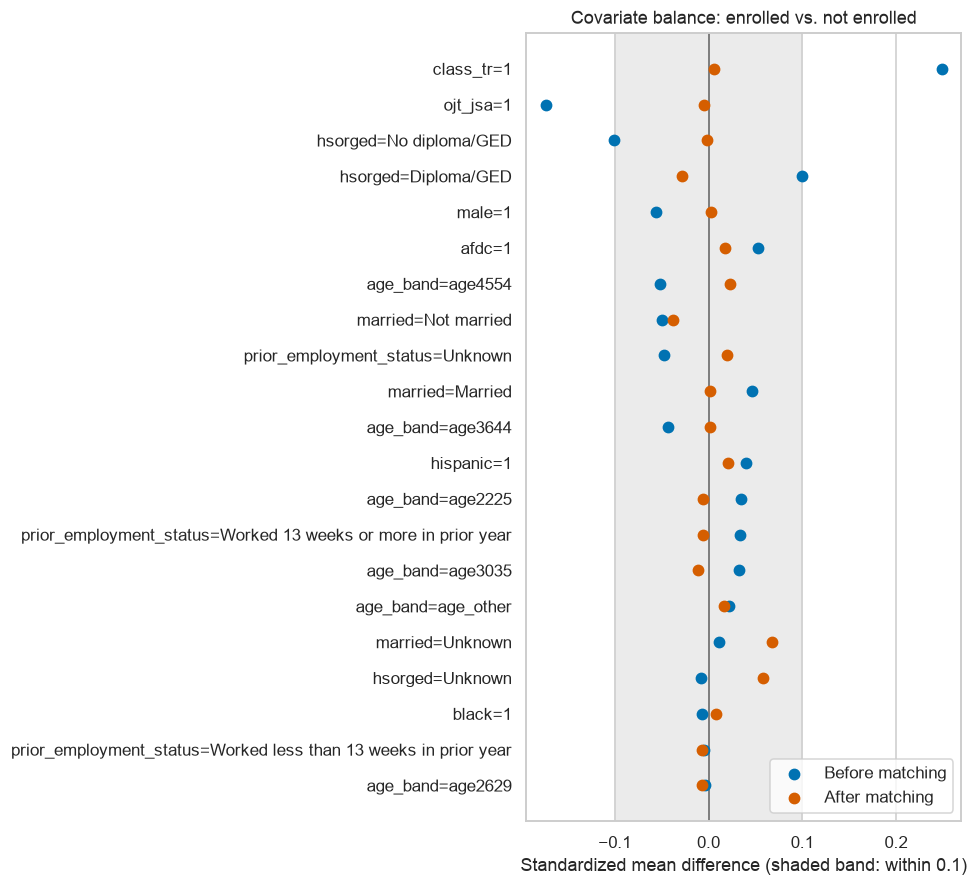

Largest absolute standardized mean difference: 0.249 before, 0.067 after.


In [11]:
# Treated people count once; untreated people count as often as they were matched.
att_weights = matches["times_used"].where(~treated, 1.0)
balance_after = balance_table(X, treated, weights=att_weights).loc[balance_levels]
plot_balance(
    {"Before matching": balance_before, "After matching": balance_after},
    "matching_balance_after.png",
)
print(
    "Largest absolute standardized mean difference: "
    f"{balance_before['Std. mean difference'].abs().max():.3f} before, "
    f"{balance_after['Std. mean difference'].abs().max():.3f} after."
)

Matching removes the imbalance in service strategy and education, and every level is now within 0.1.  The `Unknown` levels get slightly worse because people with unknown values sit in rare profiles, so they are the ones most often matched inexactly.

## 6. Computing average treatment effect

We calculate `diff_in_income_i` for each person, flip its sign for the untreated so that it always reads as treated minus untreated, and average over everyone.

Standard errors use the Abadie-Imbens variance estimator, since the ordinary bootstrap is not valid for matching with replacement.  It combines how much the individual effects vary, how many times each person was used as a match, and the variance of income among people with the same covariate profile and treatment.

In [ ]:
# Step 3: each person's income minus their bias-corrected matched income.
matches["diff_in_income"] = df[Y] - matches["matched_income"] - matches["bias"]
# Treated minus untreated for everyone, with and without the bias correction.
matches["effect"] = (2 * df[T] - 1) * matches["diff_in_income"]
matches["effect_uncorrected"] = (2 * df[T] - 1) * (df[Y] - matches["matched_income"])

# Variance of income within each covariate profile and treatment group. People who are
# alone in their profile borrow their group's pooled within-profile variance.
profile_id = pd.Series(
    np.unique(X_values, axis=0, return_inverse=True)[1].ravel(), index=df.index
)
by_profile = df[Y].groupby([treated, profile_id])
squared_deviation = (df[Y] - by_profile.transform("mean")) ** 2
pooled_variance = squared_deviation.groupby(treated).sum() / (
    treated.groupby(treated).size() - profile_id.groupby(treated).nunique()
)
conditional_variance = by_profile.transform("var").fillna(treated.map(pooled_variance))
print(
    f"Alone in their profile and group: {by_profile.transform('size').eq(1).mean():.1%} of people."
)


def matching_estimate(effect, sample, variance_weight, estimand):
    """Mean effect over `sample` with an Abadie-Imbens standard error."""
    estimate = effect[sample].mean()
    variance = (
        ((effect[sample] - estimate) ** 2).sum()
        + (variance_weight * conditional_variance).sum()
    ) / sample.sum() ** 2
    se = np.sqrt(variance)
    return {
        "Estimand": estimand,
        "Estimate ($)": estimate,
        "SE ($)": se,
        "95% CI lower ($)": estimate - 1.96 * se,
        "95% CI upper ($)": estimate + 1.96 * se,
        "N": int(sample.sum()),
    }


def show_estimates(estimates):
    dollar_columns = [name for name in estimates if "($)" in name]
    display(
        estimates.style.format(
            {**{name: "${:,.2f}" for name in dollar_columns}, "N": "{:,.0f}"}
        )
    )

Alone in their profile and group: 13.3% of people.


In [ ]:
# Step 4: average over everyone. K is times_used and K' is times_used_sq.
everyone = pd.Series(True, index=df.index)
ate_variance_weight = (
    matches["times_used"] ** 2 + 2 * matches["times_used"] - matches["times_used_sq"]
)
ate_estimates = pd.DataFrame.from_dict(
    {
        "Matching ATE": matching_estimate(
            matches["effect"],
            everyone,
            ate_variance_weight,
            "Enrollment effect for everyone",
        ),
        "Matching ATE, no bias correction": matching_estimate(
            matches["effect_uncorrected"],
            everyone,
            ate_variance_weight,
            "Enrollment effect for everyone",
        ),
    },
    orient="index",
)
show_estimates(ate_estimates)

,Estimand,Estimate ($),SE ($),95% CI lower ($),95% CI upper ($),N
Matching ATE,Enrollment effect for everyone,"$2,942.33",$322.64,"$2,309.95","$3,574.71","11,204"
"Matching ATE, no bias correction",Enrollment effect for everyone,"$2,967.91",$322.65,"$2,335.52","$3,600.30","11,204"


## 7. Computing average treatment effect of treated

Here we average `diff_in_income_i` over the treated only, so only the untreated people used as their matches add matching noise to the variance.

In [ ]:
# Step 5: average over the treated. Only untreated matches contribute K^2 - K'.
atet_variance_weight = (matches["times_used"] ** 2 - matches["times_used_sq"]).where(
    ~treated, 0.0
)
atet_estimates = pd.DataFrame.from_dict(
    {
        "Matching ATET": matching_estimate(
            matches["effect"],
            treated,
            atet_variance_weight,
            "Enrollment effect for the treated",
        ),
        "Matching ATET, no bias correction": matching_estimate(
            matches["effect_uncorrected"],
            treated,
            atet_variance_weight,
            "Enrollment effect for the treated",
        ),
    },
    orient="index",
)
show_estimates(atet_estimates)

,Estimand,Estimate ($),SE ($),95% CI lower ($),95% CI upper ($),N
Matching ATET,Enrollment effect for the treated,"$2,930.72",$334.74,"$2,274.63","$3,586.82","4,858"
"Matching ATET, no bias correction",Enrollment effect for the treated,"$2,866.23",$334.75,"$2,210.13","$3,522.33","4,858"


## 8. Comparing the estimates

We put the matching estimates next to the naive enrollment regression and the controlled IV estimate from the [IV notebook](03_iv_regression.ipynb).

In [15]:
matching_estimates = pd.concat([ate_estimates, atet_estimates])
matching_estimates.index.name = "Model"
matching_estimates.to_csv(TABLES_DIR / "matching_estimates.csv")

iv_comparison = pd.read_csv(TABLES_DIR / "model_comparison.csv", index_col="Model")
comparison = pd.concat(
    [
        iv_comparison.loc[["Enrollment OLS", "Controlled IV"]].rename(
            columns={"Robust SE ($)": "SE ($)"}
        )[matching_estimates.columns],
        matching_estimates.loc[["Matching ATE", "Matching ATET"]],
    ]
)
show_estimates(comparison)

,Estimand,Estimate ($),SE ($),95% CI lower ($),95% CI upper ($),N
Model,,,,,,
Enrollment OLS,Enrollment association,"$2,791.09",$319.90,"$2,164.03","$3,418.15","11,204"
Controlled IV,Enrollment effect for compliers*,"$1,770.87",$497.66,$795.38,"$2,746.37","11,204"
Matching ATE,Enrollment effect for everyone,"$2,942.33",$322.64,"$2,309.95","$3,574.71","11,204"
Matching ATET,Enrollment effect for the treated,"$2,930.72",$334.74,"$2,274.63","$3,586.82","4,858"


## 9. Conclusion

Matching estimates that enrolling raises 30-month earnings by about $2,942 for everyone (SE $323) and $2,931 for the treated (SE $335).  The bias correction barely matters, as expected with so many exact matches.

Matching did not move us toward the IV estimate.  The effect for the treated is the number most comparable to the controlled IV estimate of $1,771, and it sits about $1,160 above it, slightly higher even than the naive $2,791.  This is what the balance checks predicted: the enrolled and not enrolled already looked alike on the observed controls, so adjusting for those controls changes little, and the selection the DAG warned about (motivation, baseline skills, local market conditions) is left untouched.  My guess at the top of this notebook, that matching would land between the naive and IV estimates, was wrong.  This offers strong evidence that the unobserved confounders are doing much more confounding than our observed ones.

The two confidence intervals overlap (about $2,275 to $3,587 for matching, $795 to $2,746 for IV), so these data alone do not prove the estimates differ.  But the direction is what we would expect if people who choose to enroll would have earned more anyway, and only the randomized offer lets us separate that from the effect of the program.